In [28]:
import pandas as pd
from collections import Counter
from dqn.dqn_config import HYPER_PARAMS
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter


## Agent Component Distribution
**Number of Component vs. Occurrence Frequency**:Number of component that have $X$ occurrences

In [18]:
###* loading Agent Data
# Folder containing the csv files
DIR = os.path.join(HYPER_PARAMS.agent_data_dir,"train",'transition_csv_DoubleDQN_OnRL_16e6')
DIR_CLEAN = os.path.join(HYPER_PARAMS.agent_data_dir,"train",'transition_csv_DoubleDQN_OnRL_16e6_cleaned')

# Get path of all CSV file 
csv_files=[os.path.join(DIR, f) for f in os.listdir(DIR)  if f.endswith('.csv')]
csv_files_clean=[os.path.join(DIR_CLEAN, f) for f in os.listdir(DIR_CLEAN)  if f.endswith('.csv')]

# Read and combine all CSV files into one DataFrame
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df_clean = pd.concat([pd.read_csv(f) for f in csv_files_clean], ignore_index=True)

In [ ]:
def component_distibution(df, tag,suffix=""):
    if tag=="actions":
        cols_name=[tag]
    elif tag =="states":
        cols_name=df.columns[1:18]
    elif tag=="state-action":
        cols_name=df.columns[1:19]
    elif tag == "transitions":
        cols_name=[c for c in df.columns if c != "trans_idx"]
    else:
        raise ValueError(f"Unknown tag: {tag}")
    
    
    # Convert each componet to a tuple
    components = df[cols_name].itertuples(index=False, name=None)

    # Count occurrences of each unique component
    component_counter = Counter(components)

    # Distribution:  occurrence -> number of transitions
    occurrence_distribution = Counter(component_counter.values())

    distribution_df = (
        pd.DataFrame({
            "occurrences": list(occurrence_distribution.keys()),
            "num_"+tag: list(occurrence_distribution.values())
        })
        .sort_values("occurrences")
    )

    print(f"\nTotal unique {tag}: {len(component_counter):,}")
    print(f"Maximum occurrence: {max(component_counter.values()):,}")

    distribution_df.to_csv(f"{tag}_distribution{suffix}.csv", index=False)
    del distribution_df
    

In [38]:
def plot_component_distibution(min_bound:int, max_bound:int,figsize:tuple, tag:str,suffix=""): 
        df = pd.read_csv(tag+"_distribution"+suffix+".csv")
        # Data
        x = df["occurrences"].to_numpy()
        y = df["num_"+tag].to_numpy()
        mask =  (x >= min_bound) & (x < max_bound)
        # Plot
        fig, ax =plt.subplots(figsize=figsize)

        ax.scatter(
            x[mask],
            y[mask],
            alpha=0.5,
            color='blue',
        )

        ax.set_ylabel("Number of "+tag, fontsize=16)
        ax.set_xlabel("Frequency",fontsize=16) 
        # ----------------Logarithmic Y-axis--------------------------

        ax.set_yscale("log")        

        if y[mask].max()> 1e2:
            ax.set_ylim(0, 1e7)
        else:
            ax.set_ylim(0, 1e2)


        # Major ticks at every power of 10
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

        # Minor ticks at 2,3,...,9 within each decade
        # if y[mask].max()< 1e2:
        #     ax.yaxis.set_minor_locator(LogLocator(base=10, subs=range(2, 10)))

        # Only label the minor ticks between 10^0 and 10^1
        def minor_formatter(y, pos):
            if 1 < y < 10:
                return f"{int(y)}"
            return ""
        if y[mask].max()< 1e2:
            ax.yaxis.set_minor_formatter(FuncFormatter(minor_formatter))

        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        ax.tick_params(axis='x',rotation=45)  # Rotate the x-axis tick labels

        plt.tight_layout()  # auto-fixes spacing so your plot doesn’t look cramped or cut off
        plt.savefig(f"./fig/{tag}_distribution{suffix}_[{min_bound},{max_bound}].pdf", format="pdf")

## Transition Distribution

In [5]:
component_distibution(df, "transitions")


Total unique transitions: 7,985,473
Maximum occurrence: 46,368


/tmp/ipykernel_4119/3593492217.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e7)
/tmp/ipykernel_4119/3593492217.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e2)


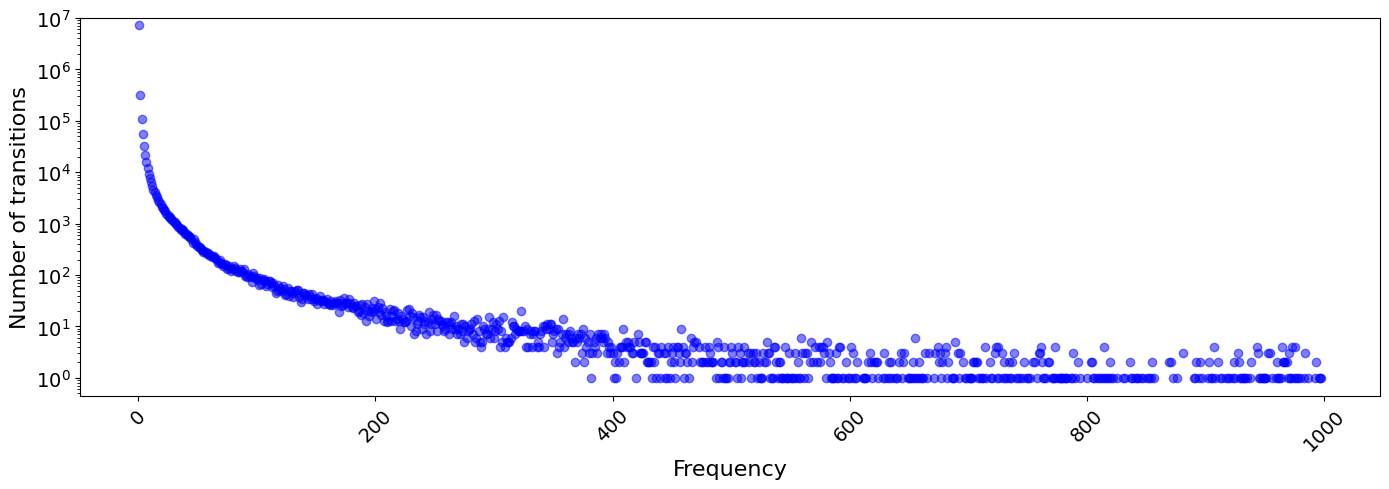

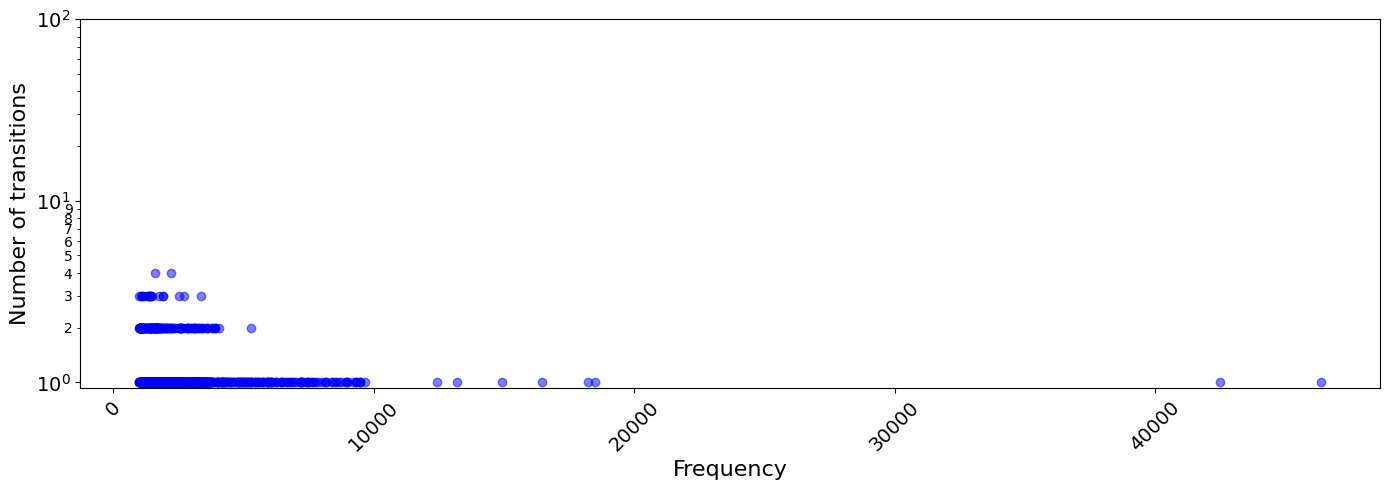

In [39]:
plot_component_distibution(min_bound=1, max_bound=1001,figsize=(14, 5), tag="transitions")
# plot_component_distibution(min_bound=701, max_bound=46368,figsize=(14, 5), tag="transitions")
plot_component_distibution(min_bound=1001, max_bound=46370,figsize=(14,5), tag="transitions")

## State Distribution

In [7]:
component_distibution(df, tag="states")


Total unique states: 6,934,314
Maximum occurrence: 78,609


/tmp/ipykernel_4119/949853007.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e7)
/tmp/ipykernel_4119/949853007.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e2)


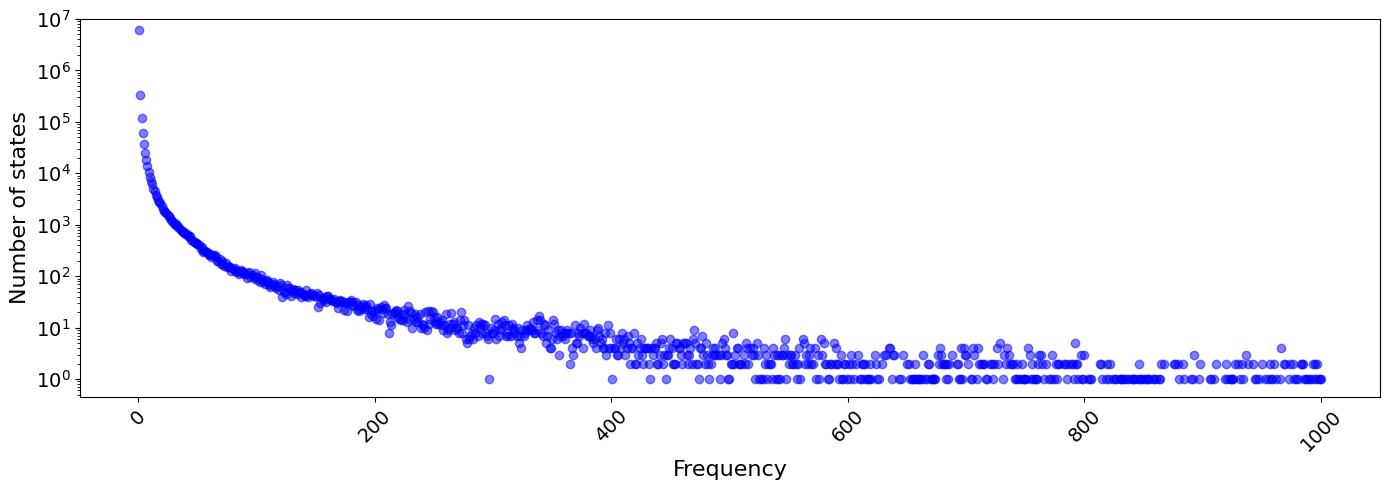

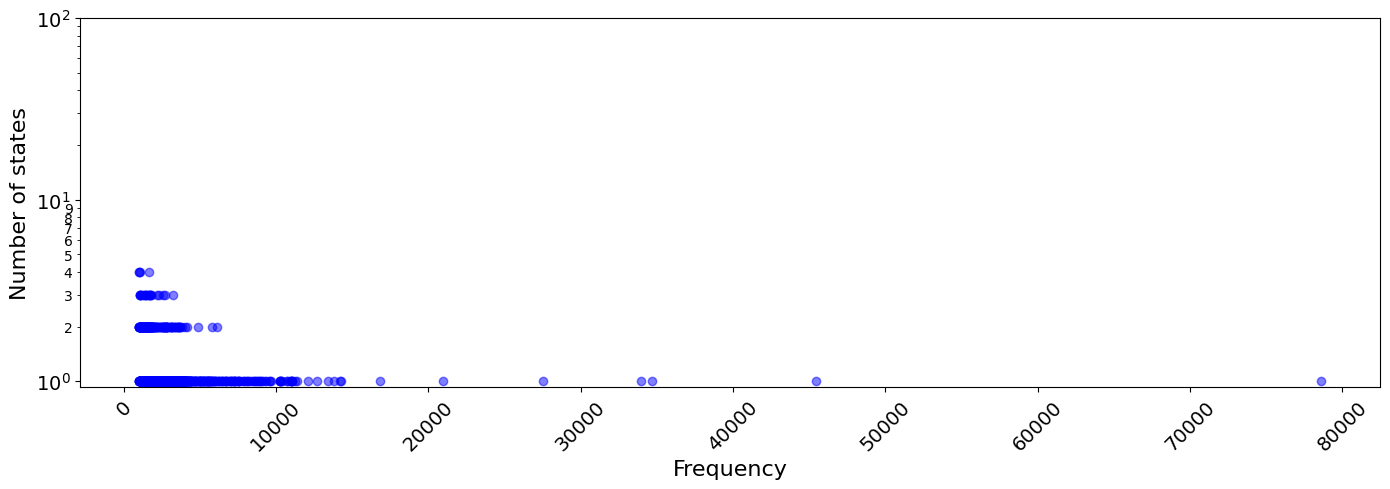

In [31]:
plot_component_distibution(min_bound=1, max_bound=1001,figsize=(14, 5), tag="states")
# plot_component_distibution(min_bound=501, max_bound=1001,figsize=(18, 8), tag="states")
plot_component_distibution(min_bound=1001, max_bound=78610,figsize=(14, 5), tag="states")

In [9]:
component_distibution(df_clean, tag="states", suffix="_cleaned")


Total unique states: 6,934,314
Maximum occurrence: 6,369


/tmp/ipykernel_4119/949853007.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e7)
/tmp/ipykernel_4119/949853007.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e2)


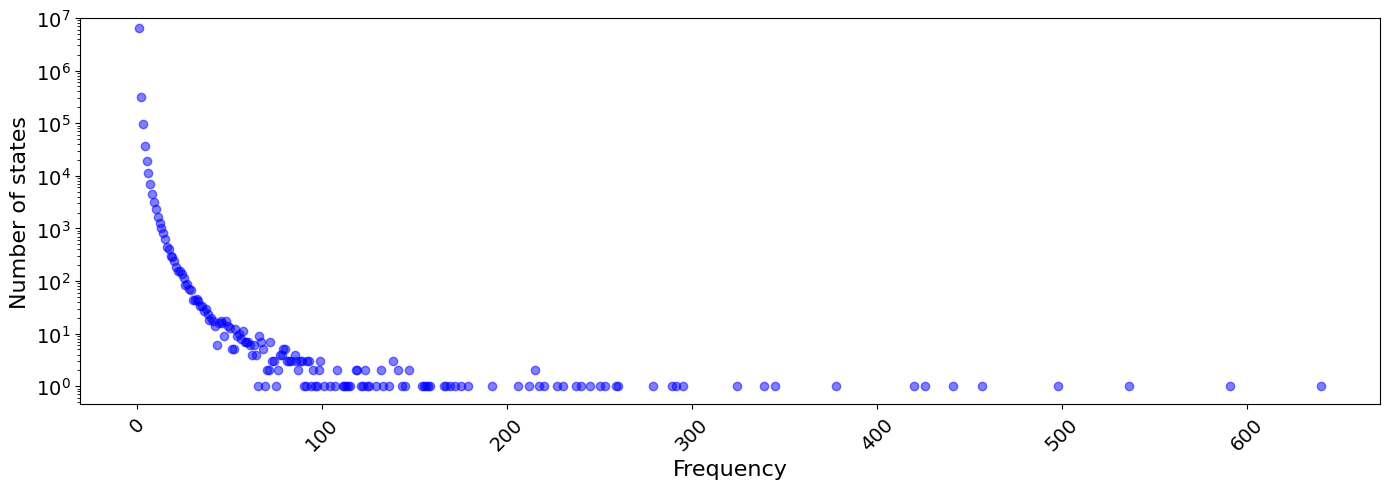

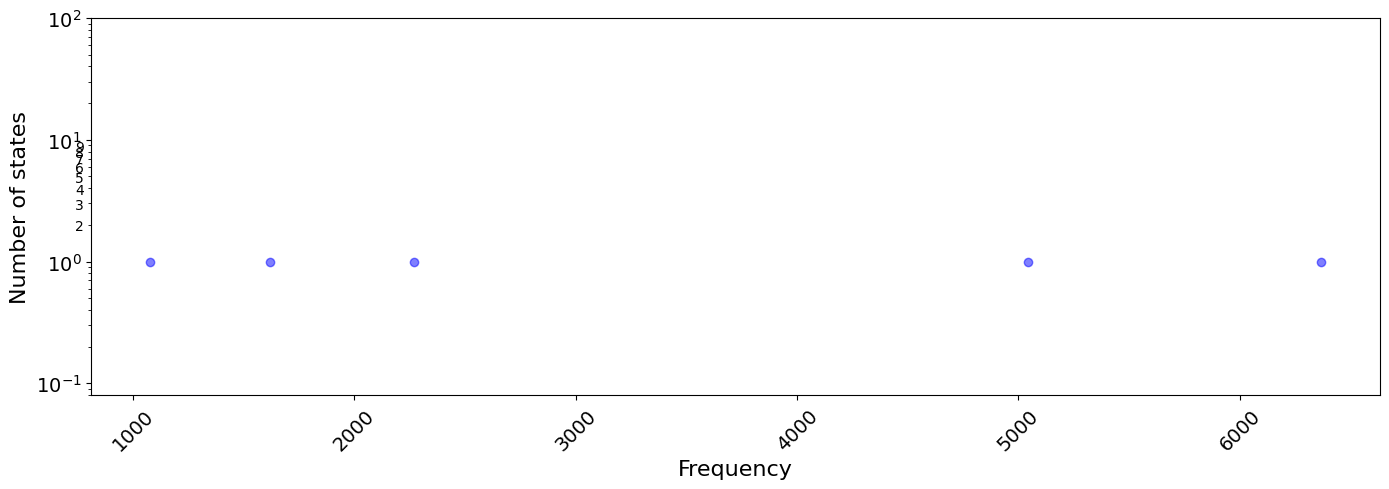

In [32]:
plot_component_distibution(min_bound=1, max_bound=1001,figsize=(14, 5), tag="states", suffix="_cleaned")
plot_component_distibution(min_bound=1001, max_bound=6370,figsize=(14, 5), tag="states", suffix="_cleaned")

## State-Action distribution 

In [30]:
component_distibution(df, tag="state-action")


Total unique state-action: 7,257,319
Maximum occurrence: 59,498


/tmp/ipykernel_4119/949853007.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e7)
/tmp/ipykernel_4119/949853007.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e2)


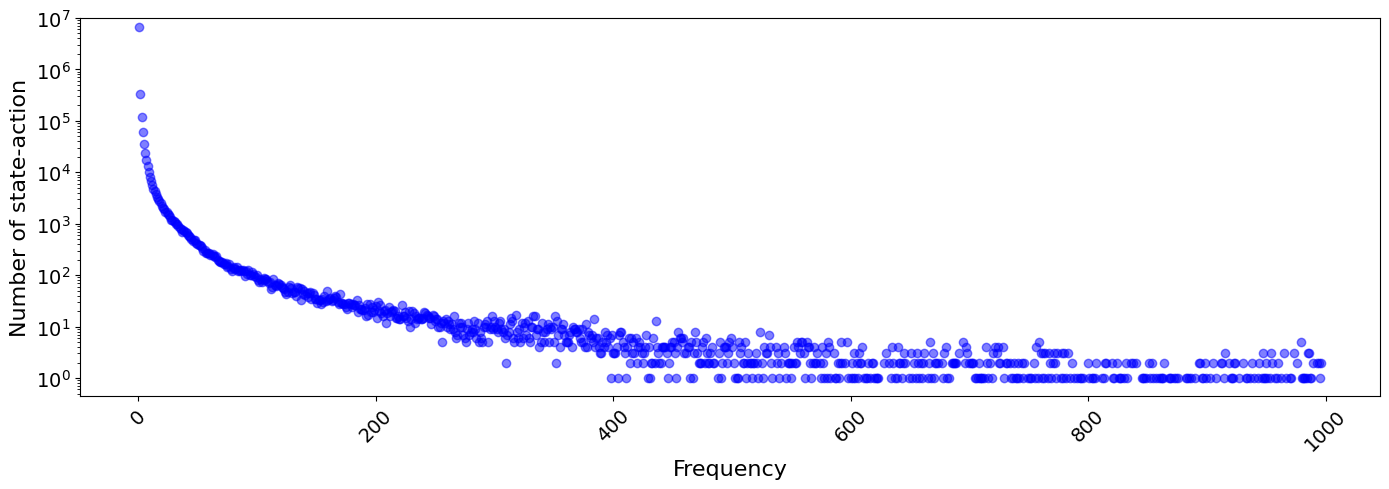

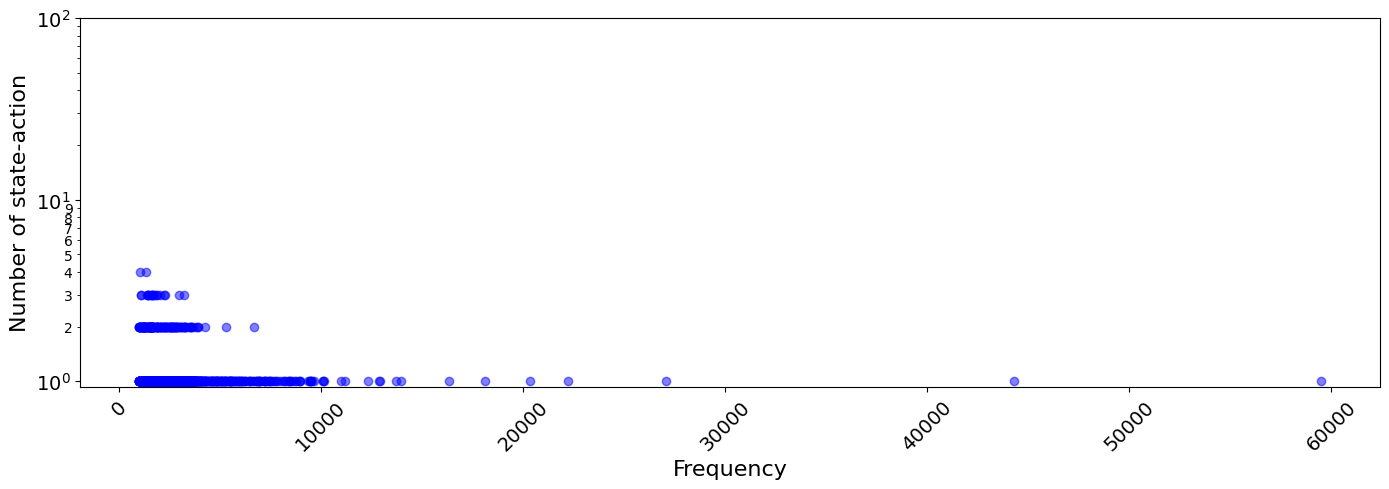

In [33]:
plot_component_distibution(min_bound=1, max_bound=1001,figsize=(14, 5), tag="state-action")
plot_component_distibution(min_bound=1001, max_bound=59499,figsize=(14, 5), tag="state-action")

In [31]:
component_distibution(df_clean, tag="state-action", suffix="_cleaned")


Total unique state-action: 7,257,319
Maximum occurrence: 3,240


/tmp/ipykernel_4119/949853007.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e7)
/tmp/ipykernel_4119/949853007.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e2)


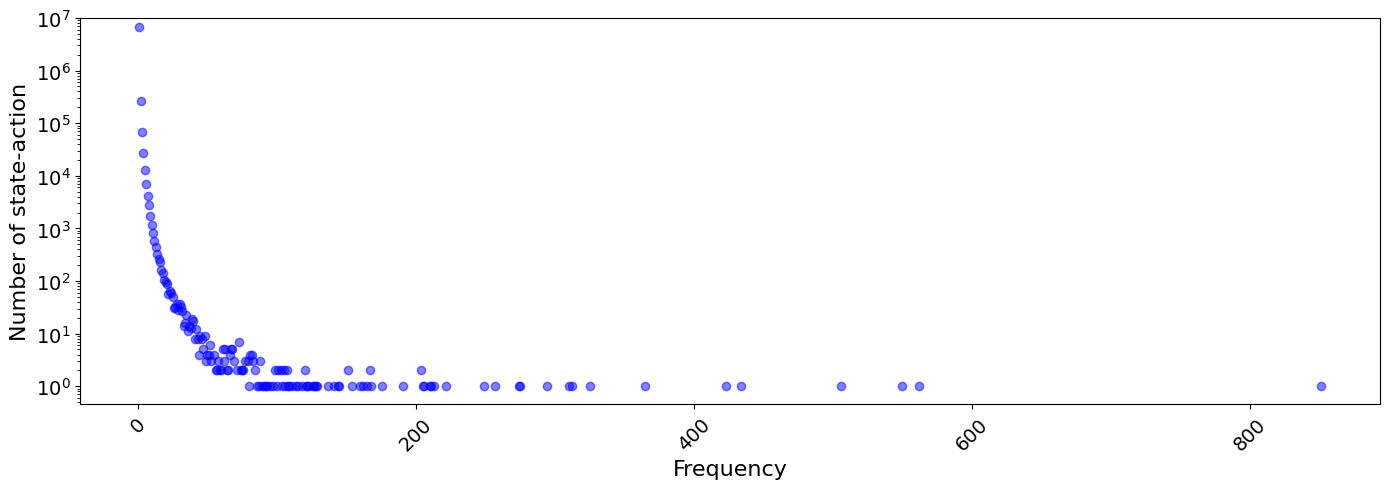

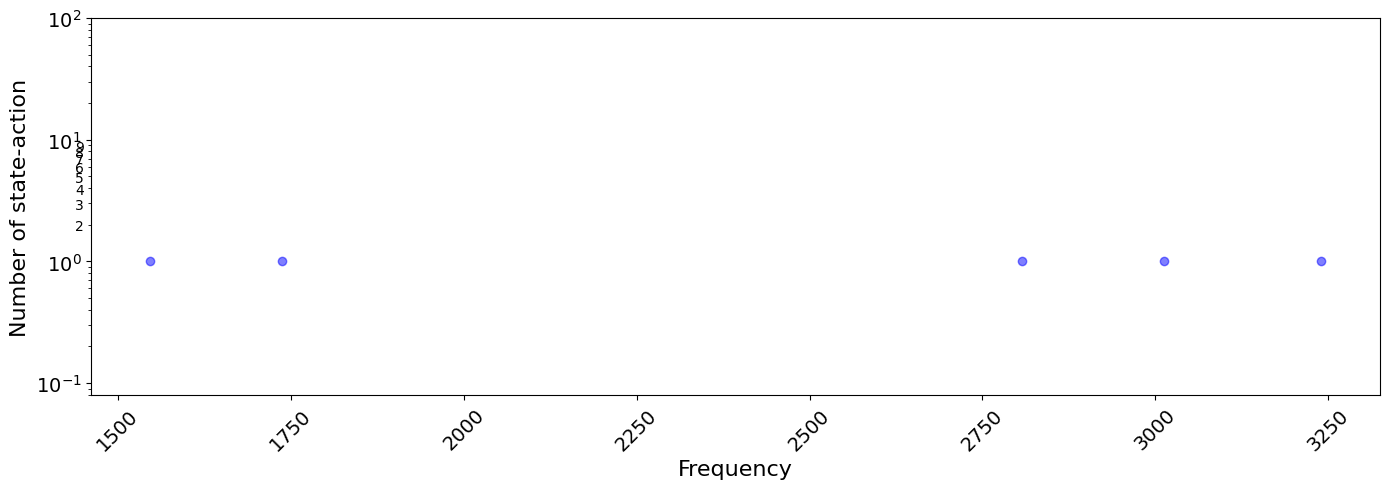

In [35]:
plot_component_distibution(min_bound=1, max_bound=1001,figsize=(14, 5), tag="state-action", suffix="_cleaned")  
plot_component_distibution(min_bound=1001, max_bound=3241,figsize=(14, 5), tag="state-action", suffix="_cleaned")

## Action Distribution

In [42]:
def action_distribution(df, suffix=""):
    action_counts = df["action"].value_counts().sort_index()
    if suffix == "":
        print("Action distribution of the original data:")
    else:
        print("Action distribution of the cleaned data:")

    print(action_counts,"\n\n")
    # Mapping
    action_labels = {
        0: "Right LC",
        1: "Lane Keeping",
        2: "Left LC"
    }

    # Replace indices with labels
    labels = [action_labels.get(i, f"Action {i}") for i in action_counts.index]

        # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(labels, action_counts.values, width=0.8)

    ax.set_ylim(0, max(action_counts.values) * 1.15) 

    # Show values on top of bars
    ax.bar_label(
        bars,
        labels=[str(c) for c in action_counts.values],
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

    plt.xlabel("Action",fontsize=16)
    plt.ylabel("Frequency",fontsize=16)
    plt.title("Action distribution")
    

    plt.xticks(labels)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(f"./fig/action_distribution{suffix}.pdf", format="pdf")


Action distribution of the original data:
action
0     1274111
1    13040270
2     1735623
Name: count, dtype: int64 


Action distribution of the cleaned data:
action
0    1079866
1    5500767
2    1404840
Name: count, dtype: int64 




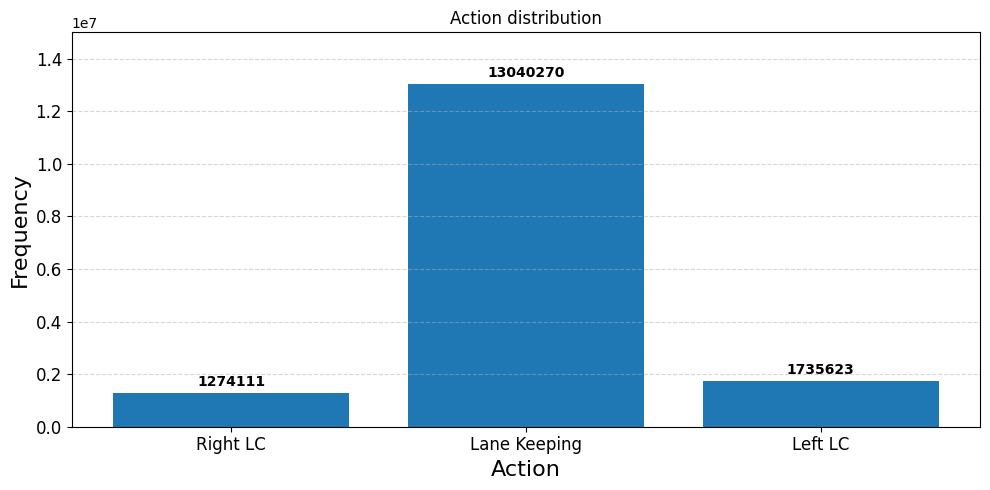

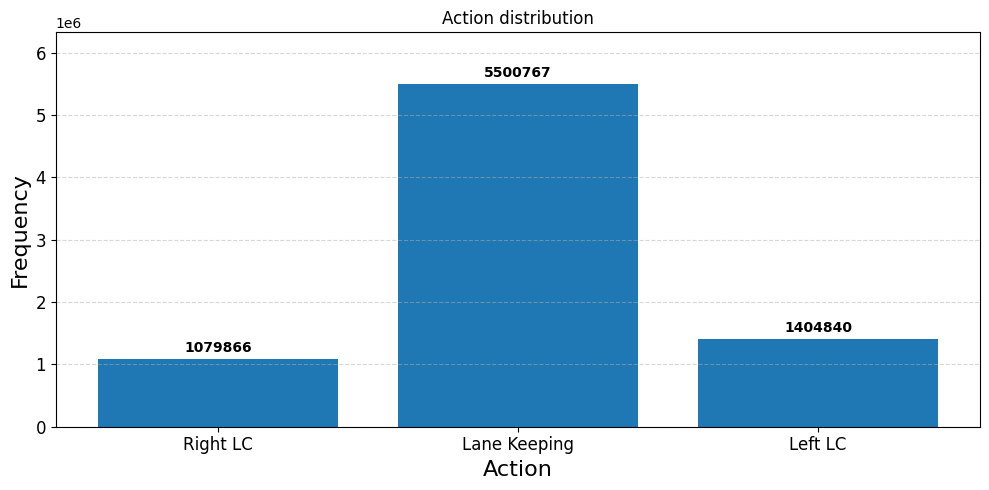

In [43]:
action_distribution(df)
action_distribution(df_clean, suffix="_cleaned")

## State-action coverge
 same result with original and cleaned data

In [55]:
# State columns (columns 1 to 18, excluding trans_idx)
state_cols = df.columns[1:18]

# For each state, collect the set of actions that were taken
state_actions = (
    df.groupby(list(state_cols))["action"]
      .apply(lambda x: frozenset(sorted(x.unique())))
)

# Count how many states have each action combination
state_action_distribution = state_actions.value_counts().sort_index()


action_label= {
    0: "RLC",
    1: "LK",
    2: "LLC"
}

# Convert to DataFrame
# state_action_distribution_df = (
#     state_action_distribution.rename_axis("actions")
#                 .reset_index(name="num_states")
# )
state_action_distribution_df = pd.DataFrame({
    "actions": [
        ",".join(map(str, sorted(actions)))
        for actions in state_action_distribution.index
    ],
    "num_states": state_action_distribution.values
})

# Add a readable action-name column
state_action_distribution_df["action_names"] = (
    state_action_distribution_df["actions"]
    .apply(lambda s: ", ".join(action_label[int(a)] for a in str(s).split(",")))
)

state_action_distribution_df.to_csv("state_action_coverage_distribution.csv", index=False)
print(state_action_distribution_df)



  actions  num_states  action_names
0       1     4629675            LK
1       2     1181489           LLC
2       0      856698           RLC
3     1,2      107235       LK, LLC
4     0,1       93042       RLC, LK
5     0,2        9622      RLC, LLC
6   0,1,2       56553  RLC, LK, LLC


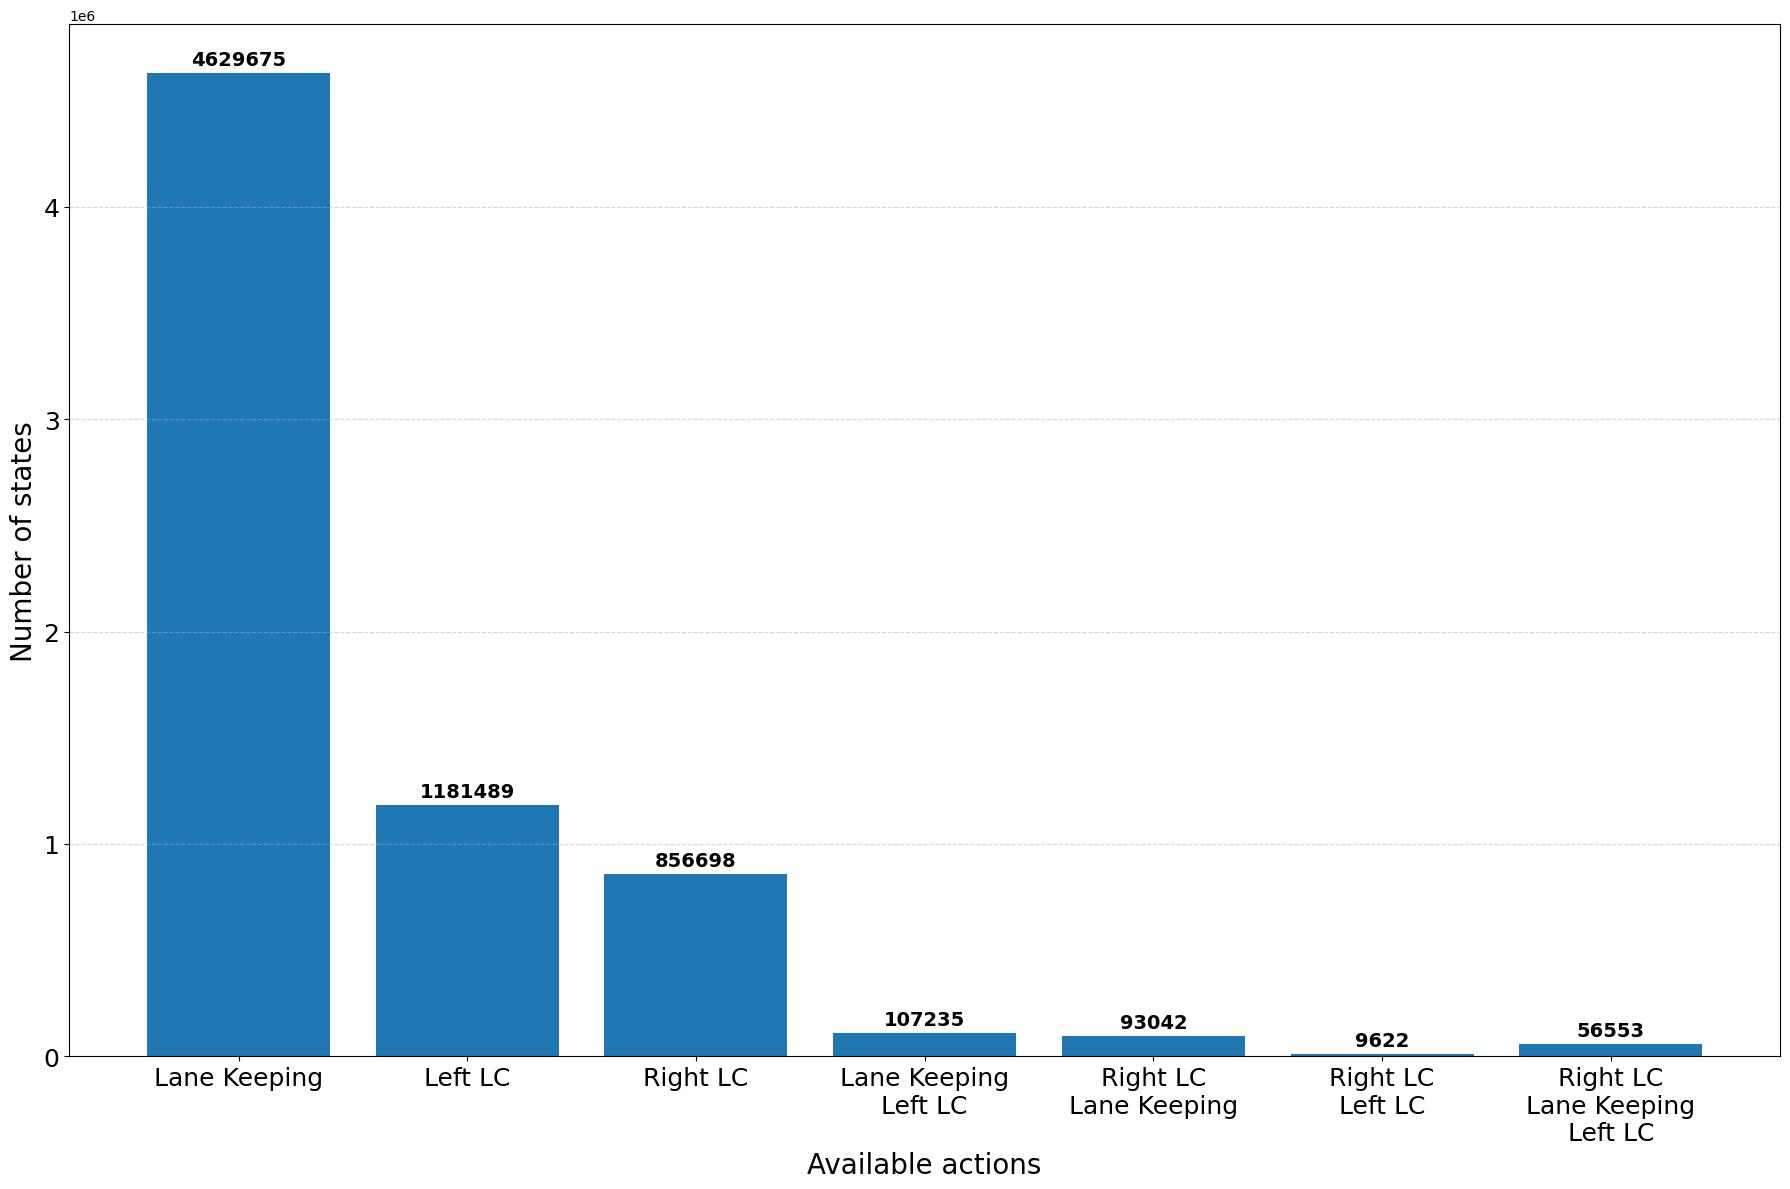

In [56]:

action_labels = {
        0: "Right LC",
        1: "Lane Keeping",
        2: "Left LC"
}

# Load the CSV
distribution_df = pd.read_csv("state_action_coverage_distribution.csv")

# Convert commas back to newlines for plotting
plot_labels = []

for actions in distribution_df["actions"]:
    idx = [int(a) for a in str(actions).split(",")]
    label = "\n".join(action_labels[a] for a in idx)
    plot_labels.append(label)

counts = distribution_df["num_states"]

# Plot
fig, ax = plt.subplots(figsize=(18, 12))

bars = ax.bar(plot_labels, counts, width=0.8)

# Show values on top of bars
ax.bar_label(
    bars,
    labels=[str(c) for c in counts],
    padding=3,
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Available actions", fontsize=20)
ax.set_ylabel("Number of states", fontsize=20)

ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"./fig/state_action_coverage_distribution.pdf", format="pdf")